In [1]:
from merge import merge_and_save, investigate

d:\Users\baher\anaconda3\envs\paddleocr_gpu\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Skipping import of the encryption module.


In [2]:
config = "../configs/rec/PP-OCRv5_inf/eslav_PP-OCRv5_mobile_rec.yml"
model_path1 = "../../pretrained/eslav_PP-OCRv5_mobile_rec_pretrained.pdparams"
model_path2 = "../output/eslav_rec_ppocr_v5_exp5/best_accuracy.pdparams"
save_path = "../output/new_slerp05_bn_base/best_accuracy.pdparams"

In [3]:
stats = investigate(model_path1, model_path2, config)

[2026/01/06 16:21:08] ppocr INFO: load pretrain successful from ../../pretrained/eslav_PP-OCRv5_mobile_rec_pretrained
[2026/01/06 16:21:09] ppocr INFO: load pretrain successful from ../output/eslav_rec_ppocr_v5_exp5/best_accuracy


In [4]:
import numpy as np
import pandas as pd

def analyze_model_divergence(stats, top_k=10, combine_metrics=True):
    """
    Analyze divergence between base and fine-tuned model layers.

    Args:
        stats (dict): Dict with keys -> {'r_ratio', 'cos_sim', 'mse'}
        top_k (int): Number of top divergent layers to return
        combine_metrics (bool): Whether to compute a combined anomaly score

    Returns:
        dict: {
            'top_r_ratio_diff': [...],
            'top_cos_sim_diff': [...],
            'top_mse_diff': [...],
            'combined_top': [...]  # if combine_metrics=True
        }
    """
    # Convert to DataFrame for easier handling
    df = pd.DataFrame.from_dict(stats, orient='index')
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    if df.empty:
        raise ValueError("No valid entries in stats after NaN/inf removal.")

    results = {}

    # 1. Rank by r_ratio deviation from 1.0 (ideal ratio)
    df['r_ratio_dev'] = np.abs(df['r_ratio'] - 1.0)
    top_r = df['r_ratio_dev'].nlargest(top_k).index.tolist()
    results['top_r_ratio_diff'] = top_r

    # 2. Rank by low cosine similarity (closer to 0 or negative = more different)
    df['cos_sim_dev'] = 1.0 - df['cos_sim']  # deviation from 1.0 (perfect alignment)
    top_cos = df['cos_sim_dev'].nlargest(top_k).index.tolist()
    results['top_cos_sim_diff'] = top_cos

    # 3. Rank by high MSE
    top_mse = df['mse'].nlargest(top_k).index.tolist()
    results['top_mse_diff'] = top_mse

    # 4. (Optional) Combined anomaly score
    if combine_metrics:
        # Normalize each deviation metric to [0,1]
        r_norm = (df['r_ratio_dev'] - df['r_ratio_dev'].min()) / (df['r_ratio_dev'].max() - df['r_ratio_dev'].min() + 1e-8)
        cos_norm = (df['cos_sim_dev'] - df['cos_sim_dev'].min()) / (df['cos_sim_dev'].max() - df['cos_sim_dev'].min() + 1e-8)
        mse_norm = (df['mse'] - df['mse'].min()) / (df['mse'].max() - df['mse'].min() + 1e-8)

        df['combined_score'] = r_norm + cos_norm + mse_norm
        combined_top = df['combined_score'].nlargest(top_k).index.tolist()
        results['combined_top'] = combined_top

    return results

In [5]:
results = analyze_model_divergence(stats, top_k=20)

print("Most changed by norm ratio:", results['top_r_ratio_diff'])
print("Most changed by cosine sim:", results['top_cos_sim_diff'])
print("Most changed by MSE:", results['top_mse_diff'])
print("Combined top:", results.get('combined_top'))

Most changed by norm ratio: ['backbone.blocks6.1.pw_conv.identity._variance', 'backbone.blocks6.3.dw_conv.identity.bias', 'backbone.conv1.bn._mean', 'backbone.blocks6.1.pw_conv.conv_kxk.0.bn._variance', 'backbone.blocks6.3.dw_conv.conv_kxk.3.bn._variance', 'backbone.blocks6.1.pw_conv.conv_kxk.1.bn._variance', 'backbone.blocks6.1.pw_conv.conv_kxk.2.bn._variance', 'backbone.blocks6.1.pw_conv.conv_kxk.3.bn._variance', 'backbone.blocks6.3.dw_conv.identity.weight', 'backbone.blocks6.3.dw_conv.conv_kxk.2.bn._variance', 'backbone.blocks6.3.dw_conv.conv_kxk.1.bn._variance', 'head.gtc_head.embedding.embedding.weight', 'backbone.blocks6.2.dw_conv.conv_kxk.1.bn._variance', 'head.ctc_encoder.encoder.conv3.norm._variance', 'backbone.blocks5.1.pw_conv.identity._variance', 'backbone.blocks5.0.dw_conv.act.lab.bias', 'backbone.blocks3.0.dw_conv.conv_1x1.bn._variance', 'backbone.blocks6.2.dw_conv.conv_kxk.3.bn._variance', 'backbone.blocks6.3.dw_conv.conv_kxk.0.bn._variance', 'head.gtc_head.decoder.0.mlp

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_layer_divergence_histograms(stats, bins=20, figsize=(15, 4)):
    """
    Plot histograms for r_ratio, cos_sim, and mse to visualize layer-wise divergence.
    
    Args:
        stats (dict): Dictionary with keys -> {'r_ratio', 'cos_sim', 'mse'}
        bins (int): Number of histogram bins
        figsize (tuple): Figure size
    """
    # Convert to DataFrame
    df = pd.DataFrame.from_dict(stats, orient='index')
    
    # Remove invalid values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    
    if df.empty:
        print("No valid data to plot.")
        return

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle('Distribution of Layer-Wise Divergence Metrics', fontsize=14, weight='bold')

    # 1. r_ratio (ideal = 1.0)
    axes[0].hist(df['r_ratio'], bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(1.0, color='red', linestyle='--', label='Ideal (ratio=1)')
    axes[0].set_title('Norm Ratio (||W_finetuned|| / ||W_base||)')
    axes[0].set_xlabel('r_ratio')
    axes[0].set_ylabel('Number of Layers')
    axes[0].legend()

    # 2. cos_sim (ideal = 1.0)
    axes[1].hist(df['cos_sim'], bins=bins, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1].axvline(1.0, color='red', linestyle='--', label='Ideal (cos=1)')
    axes[1].set_title('Cosine Similarity')
    axes[1].set_xlabel('cos_sim')
    axes[1].set_ylabel('Number of Layers')
    axes[1].legend()

    # 3. mse (ideal = 0.0)
    axes[2].hist(df['mse'], bins=bins, color='salmon', edgecolor='black', alpha=0.7)
    axes[2].axvline(0.0, color='red', linestyle='--', label='Ideal (mse=0)')
    axes[2].set_title('Mean Squared Error (MSE)')
    axes[2].set_xlabel('mse')
    axes[2].set_ylabel('Number of Layers')
    axes[2].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



def count_layers_in_ranges(stats):
    df = pd.DataFrame.from_dict(stats, orient='index')
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    total = len(df)
    print(f"Total valid layers: {total}\n")

    # Define meaningful ranges
    low_cos = df[df['cos_sim'] < 0.9]
    mid_cos = df[(df['cos_sim'] >= 0.9) & (df['cos_sim'] < 0.98)]
    high_cos = df[df['cos_sim'] >= 0.98]

    large_ratio = df[(df['r_ratio'] < 0.8) | (df['r_ratio'] > 1.2)]
    small_mse = df[df['mse'] < df['mse'].quantile(0.25)]

    print(f"Layers with LOW cosine similarity (< 0.9): {len(low_cos)} ({len(low_cos)/total:.1%})")
    print(f"Layers with MODERATE cosine (0.9–0.98): {len(mid_cos)} ({len(mid_cos)/total:.1%})")
    print(f"Layers with HIGH cosine (≥ 0.98): {len(high_cos)} ({len(high_cos)/total:.1%})\n")

    print(f"Layers with LARGE norm change (<0.8 or >1.2): {len(large_ratio)} ({len(large_ratio)/total:.1%})")
    print(f"Layers with LOW MSE (bottom 25%): {len(small_mse)} ({len(small_mse)/total:.1%})")

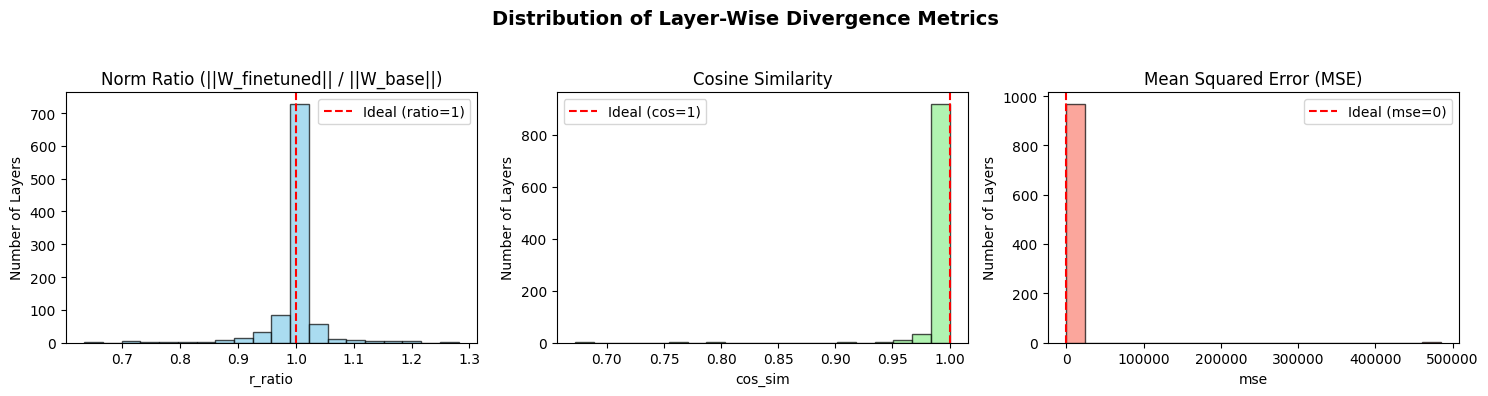

In [7]:
plot_layer_divergence_histograms(stats)

In [13]:
count_layers_in_ranges(stats)

Total valid layers: 968

Layers with LOW cosine similarity (< 0.9): 3 (0.3%)
Layers with MODERATE cosine (0.9–0.98): 34 (3.5%)
Layers with HIGH cosine (≥ 0.98): 931 (96.2%)

Layers with LARGE norm change (<0.8 or >1.2): 9 (0.9%)
Layers with LOW MSE (bottom 25%): 242 (25.0%)


In [18]:
def filter_stats_keys(stats, exclude_patterns=("_mean", "_variance", "bn", "lab", "identity", "norm", "gtc")):
    """
    Remove entries from stats whose keys contain any of the exclude_patterns.
    
    Args:
        stats (dict): Original stats dictionary
        exclude_patterns (tuple): Substrings that, if found in a key, cause exclusion
    
    Returns:
        dict: Filtered stats dictionary
    """
    filtered_stats = {
        key: value for key, value in stats.items()
        if not any(pattern in key.lower() for pattern in exclude_patterns)
    }
    return filtered_stats

filtered_stats = filter_stats_keys(stats)

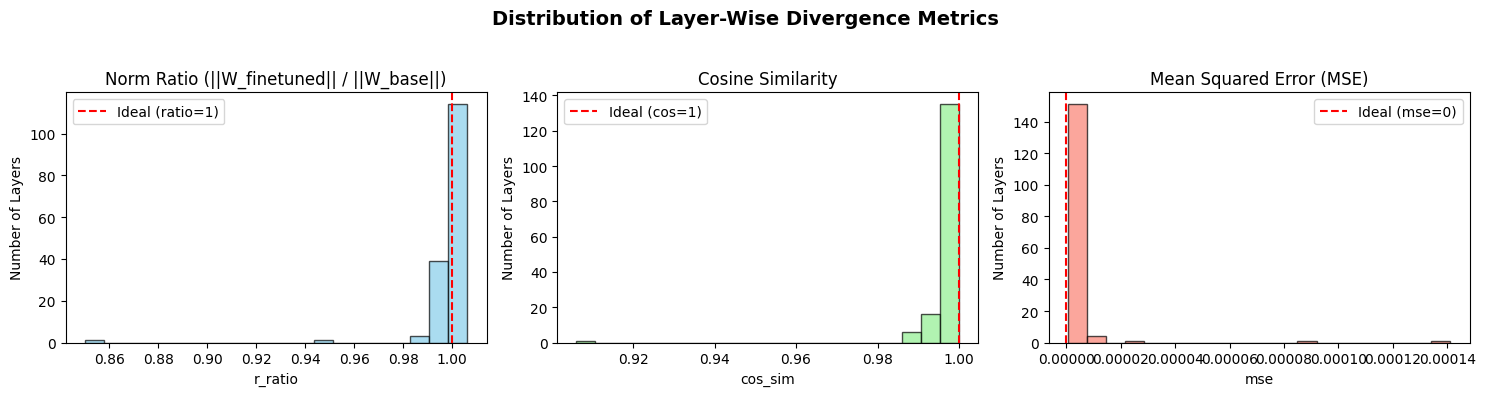

In [19]:
plot_layer_divergence_histograms(filtered_stats)

In [21]:
results = analyze_model_divergence(filtered_stats, top_k=5)

print("Most changed by norm ratio:", results['top_r_ratio_diff'])
print("Most changed by cosine sim:", results['top_cos_sim_diff'])
print("Most changed by MSE:", results['top_mse_diff'])
print("Combined top:", results.get('combined_top'))

Most changed by norm ratio: ['backbone.blocks6.0.se.conv1.bias', 'head.ctc_head.fc.bias', 'backbone.blocks6.0.se.conv2.bias', 'backbone.blocks6.3.dw_conv.conv_1x1.conv.weight', 'backbone.blocks6.2.pw_conv.conv_kxk.2.conv.weight']
Most changed by cosine sim: ['backbone.blocks6.0.se.conv1.bias', 'backbone.blocks6.2.pw_conv.conv_kxk.2.conv.weight', 'backbone.blocks6.3.dw_conv.conv_kxk.1.conv.weight', 'backbone.blocks6.3.dw_conv.conv_kxk.2.conv.weight', 'backbone.blocks6.3.dw_conv.conv_kxk.0.conv.weight']
Most changed by MSE: ['head.ctc_head.fc.bias', 'head.ctc_head.fc.weight', 'backbone.blocks6.3.dw_conv.conv_1x1.conv.weight', 'backbone.blocks6.0.se.conv1.bias', 'head.ctc_encoder.encoder.svtr_block.1.mlp.fc2.bias']
Combined top: ['backbone.blocks6.0.se.conv1.bias', 'head.ctc_head.fc.bias', 'head.ctc_head.fc.weight', 'backbone.blocks6.3.dw_conv.conv_1x1.conv.weight', 'backbone.blocks6.2.pw_conv.conv_kxk.2.conv.weight']


: 